In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Wrap-Up

### What You Did

* Cleaned and prepared raw environmental data
* Trained and evaluated Random Forest and MLP models
* Interpreted model behavior using SHAP
* Applied models to predict bottom dissolved oxygen at another station

### Key Idea

A complete machine learning workflow connects data, models, and interpretation.

Good data and the right model choice lead to better predictions.


####<font color="#FF69B4">PROMPT: "Please set the working directory to /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO"

In [ ]:
import os
os.chdir('/content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO"')

####<font color="#FF69B4">PROMPT: "Please use joblib load the model from SavedModels/RF/Run_1/rf_model.pkl. Features are CHLA, SALINITY, TN, TP, and WTEMP, DO is the target variable. Then, test it on a new station dataset: CBP_CleanedData/Final_Middle_StationCB5.1.csv. Name the prediction RF_Predicted_DO. Also, Please plot the scatter plot of true DO vs Predicted DO from RF for visualization."

Loading model from: /content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML-Coding/SavedModels/RF/Run_1/rf_model.pkl
Loading dataset from: /content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML-Coding/CBP_CleanedData/Final_Middle_StationCB5.1.csv
Features for prediction: ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable for comparison: DO
Random Forest model loaded successfully.
New station dataset loaded successfully.

First 5 rows of the new dataset:
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB5.1    7/24/84   6.7      9.01  1.20600  0.024   26.1  0.1
1             CB5.1    9/24/84   8.7     15.54  0.32325  0.025   23.4  2.3
2             CB5.1    10/8/84  13.4     14.80  0.96400  0.029   18.3  4.8
3             CB5.1   10/22/84   9.3     15.41  0.72700  0.017   19.6  4.9
4             CB5.1    11/5/84   6.7     15.75  0.63000  0.019   17.9  2.5

True DO values found in dataset (first 5):
0    0.1
1    2.3
2 

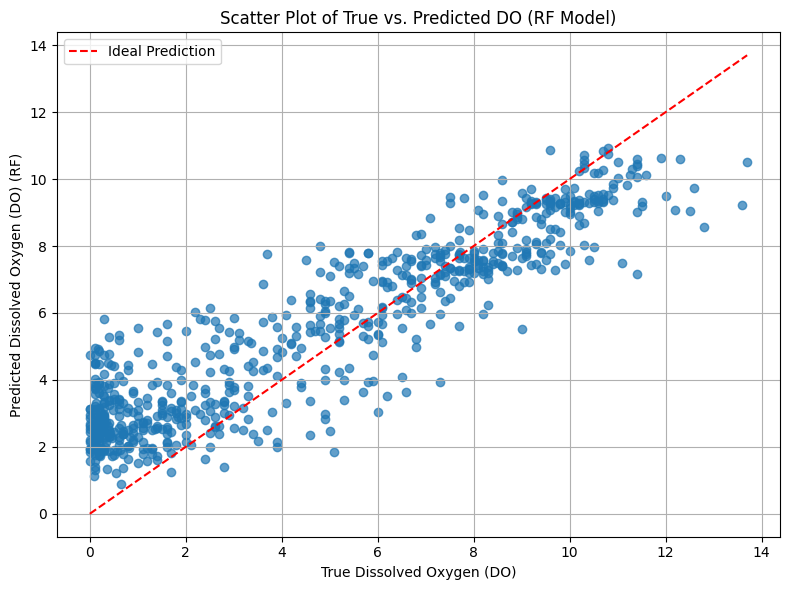

In [ ]:
import pandas as pd
import joblib
import os
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define paths relative to the current working directory
model_path = './SavedModels/RF/Run_1/rf_model.pkl'
dataset_path = './CBP_CleanedData/Final_Middle_StationCB5.1.csv'

# Define features and target as specified by the user
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_variable = 'DO'
prediction_column_name = 'RF_Predicted_DO'

print(f"Loading model from: {os.path.abspath(model_path)}")
print(f"Loading dataset from: {os.path.abspath(dataset_path)}")
print(f"Features for prediction: {feature_columns}")
print(f"Target variable for comparison: {target_variable}")

try:
    # Load the Random Forest model
    rf_model = joblib.load(model_path)
    print("Random Forest model loaded successfully.")

    # Load the new station dataset
    new_data = pd.read_csv(dataset_path)
    print("New station dataset loaded successfully.")

    # Display first few rows of the dataset to understand its structure
    print("\nFirst 5 rows of the new dataset:")
    print(new_data.head())

    # Check if all specified feature columns are in the new dataset
    missing_features = [col for col in feature_columns if col not in new_data.columns]
    if missing_features:
        raise ValueError(f"The following required features are missing in the new dataset: {missing_features}")

    # Prepare the feature matrix for prediction
    X_test = new_data[feature_columns]

    # Extract the true target variable if it exists in the dataset
    if target_variable in new_data.columns:
        y_true = new_data[target_variable]
        print(f"\nTrue {target_variable} values found in dataset (first 5):\n{y_true.head()}")
    else:
        y_true = None
        print(f"\nWarning: '{target_variable}' column not found in the dataset. Only predictions will be made.")

    # Handle potential missing values in the test set if the model expects no NaNs
    if X_test.isnull().any().any():
        print("\nWarning: Missing values found in test features. Filling with column mean.")
        X_test = X_test.fillna(X_test.mean())

    # Make predictions
    predictions = rf_model.predict(X_test)
    print("\nPredictions made successfully.")

    # Add predictions to the dataframe with the specified name
    new_data[prediction_column_name] = predictions

    print(f"\nFirst 10 rows with True {target_variable} and {prediction_column_name}:")
    if y_true is not None:
        print(new_data[[target_variable, prediction_column_name]].head(10))
    else:
        print(new_data[[prediction_column_name]].head(10))

    # If true values are available, calculate performance metrics
    if y_true is not None:
        mse = mean_squared_error(y_true, predictions)
        r2 = r2_score(y_true, predictions)
        print(f"\nModel performance on new dataset:")
        print(f"Mean Squared Error: {mse:.2f}")
        print(f"R-squared: {r2:.2f}")

    # Plotting for visualization as requested: Scatter plot of True DO vs Predicted DO
    if y_true is not None:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, new_data[prediction_column_name], alpha=0.7)
        plt.xlabel('True Dissolved Oxygen (DO)')
        plt.ylabel('Predicted Dissolved Oxygen (DO) (RF)')
        plt.title('Scatter Plot of True vs. Predicted DO (RF Model)')
        plt.grid(True)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal Prediction') # Add a diagonal line for ideal prediction
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nCannot plot scatter plot: True DO values not available in the dataset.")

except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the paths. {e}")
except ValueError as e:
    print(f"An error occurred with data processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

####<font color="#FF69B4">PROMPT: "Please plot SampleDate on the x-axis and compare the true DO and predicted DO values.

/tmp/ipykernel_19691/3604034917.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])


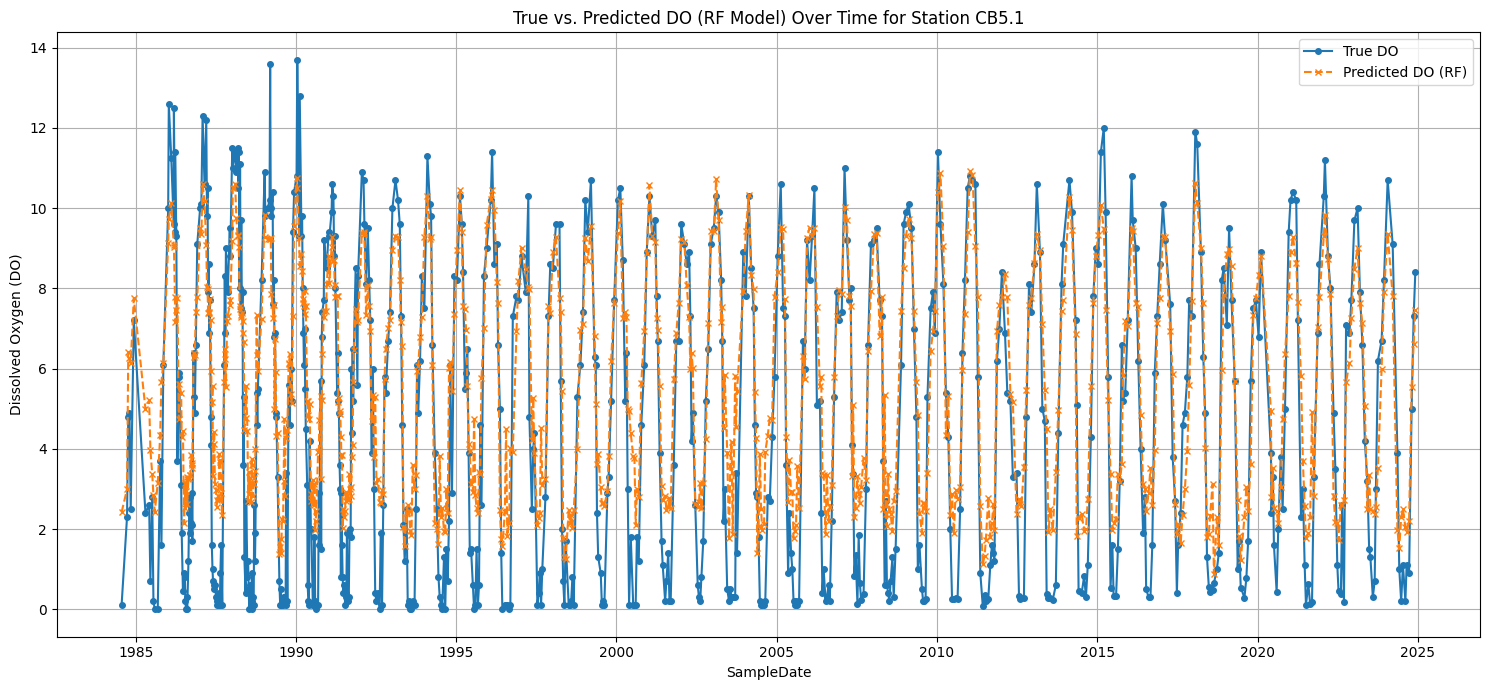

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['RF_Predicted_DO'], label='Predicted DO (RF)', marker='x', linestyle='--', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (RF Model) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: "Please load the model from SavedModels/MLP/Run_1/mlp_model.pkl. Features are CHLA, SALINITY, TN, TP, and WTEMP, DO is the target variable. Then, test it on a new station dataset: CBP_CleanedData/Final_Middle_StationCB5.1.csv. Use the standard scaler to scale the data.Name the prediction MLP_Predicted_DO Also, Please plot the scatter plot of true DO vs Predicted DO for visualization."

Loading MLP model from: /content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML-Coding/SavedModels/MLP/Run_1/mlp_model.pkl
Loading dataset from: /content/drive/MyDrive/WORKSHOP-CGC-SCIPE-AI-ML-2025-main/Day2-ML-Coding/CBP_CleanedData/Final_Middle_StationCB5.1.csv
Features for prediction: ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable for comparison: DO
MLP model loaded successfully.
New station dataset reloaded to ensure original state.

First 5 rows of the new dataset:
  MonitoringStation SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB5.1    7/24/84   6.7      9.01  1.20600  0.024   26.1  0.1
1             CB5.1    9/24/84   8.7     15.54  0.32325  0.025   23.4  2.3
2             CB5.1    10/8/84  13.4     14.80  0.96400  0.029   18.3  4.8
3             CB5.1   10/22/84   9.3     15.41  0.72700  0.017   19.6  4.9
4             CB5.1    11/5/84   6.7     15.75  0.63000  0.019   17.9  2.5

True DO values found in dataset (first 5):
0    0.1
1

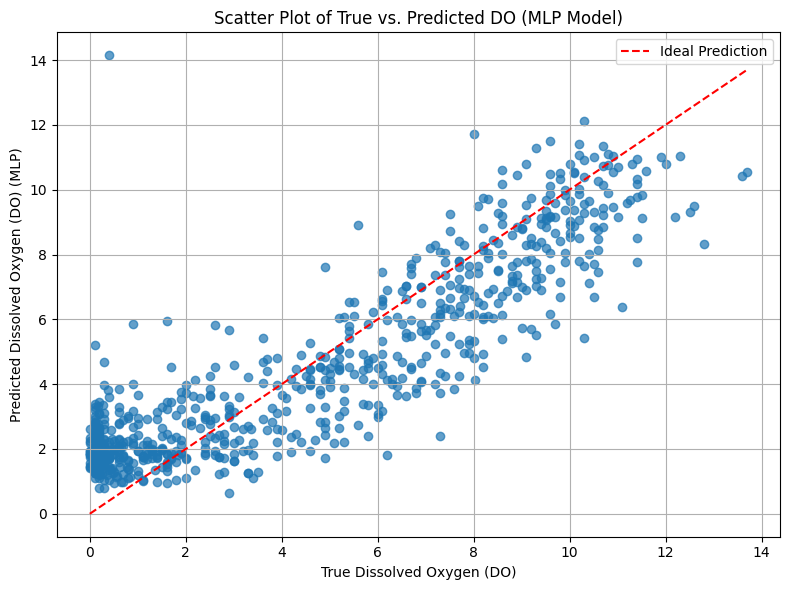

In [ ]:
import pandas as pd
import joblib
import os
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Define paths relative to the current working directory
mlp_model_path = './SavedModels/MLP/Run_1/mlp_model.pkl'
dataset_path = './CBP_CleanedData/Final_Middle_StationCB5.1.csv'

# Define features and target as specified by the user
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_variable = 'DO'
mlp_prediction_column_name = 'MLP_Predicted_DO'

print(f"Loading MLP model from: {os.path.abspath(mlp_model_path)}")
print(f"Loading dataset from: {os.path.abspath(dataset_path)}")
print(f"Features for prediction: {feature_columns}")
print(f"Target variable for comparison: {target_variable}")

try:
    # Load the MLP model
    mlp_model = joblib.load(mlp_model_path)
    print("MLP model loaded successfully.")

    # Reload the new station dataset to ensure a fresh start, especially if 'new_data' was modified by other models
    # or use the existing 'new_data' if it's guaranteed to be the original.
    # For robustness, we'll reload or ensure 'new_data' contains only original columns for feature selection.
    if 'new_data' not in globals() or not isinstance(new_data, pd.DataFrame):
        new_data = pd.read_csv(dataset_path)
        print("New station dataset loaded successfully (reloaded).")
    elif len(new_data.columns) > len(feature_columns) + 2: # heuristic to check if it has extra prediction columns
        new_data = pd.read_csv(dataset_path)
        print("New station dataset reloaded to ensure original state.")
    else:
        print("Using existing 'new_data' DataFrame.")

    # Display first few rows of the dataset to understand its structure
    print("\nFirst 5 rows of the new dataset:")
    print(new_data.head())

    # Check if all specified feature columns are in the new dataset
    missing_features = [col for col in feature_columns if col not in new_data.columns]
    if missing_features:
        raise ValueError(f"The following required features are missing in the new dataset: {missing_features}")

    # Prepare the feature matrix for prediction
    X_test_mlp = new_data[feature_columns]

    # Extract the true target variable if it exists in the dataset
    if target_variable in new_data.columns:
        y_true_mlp = new_data[target_variable]
        print(f"\nTrue {target_variable} values found in dataset (first 5):\n{y_true_mlp.head()}")
    else:
        y_true_mlp = None
        print(f"\nWarning: '{target_variable}' column not found in the dataset. Only predictions will be made.")

    # Handle potential missing values in the test set if the model expects no NaNs
    if X_test_mlp.isnull().any().any():
        print("\nWarning: Missing values found in test features. Filling with column mean.")
        X_test_mlp = X_test_mlp.fillna(X_test_mlp.mean())

    # Scale the data using StandardScaler
    # IMPORTANT: In a real-world scenario, the StandardScaler should be fitted on the training data
    # and then used to transform both training and testing data. Here, we're fitting on test data
    # because a pre-fitted scaler was not provided. This is generally NOT recommended for production.
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test_mlp)
    print("Features scaled using StandardScaler.")

    # Make predictions
    mlp_predictions = mlp_model.predict(X_test_scaled)
    print("\nPredictions made successfully.")

    # Add predictions to the dataframe with the specified name
    new_data[mlp_prediction_column_name] = mlp_predictions

    print(f"\nFirst 10 rows with True {target_variable} and {mlp_prediction_column_name}:")
    if y_true_mlp is not None:
        print(new_data[[target_variable, mlp_prediction_column_name]].head(10))
    else:
        print(new_data[[mlp_prediction_column_name]].head(10))

    # If true values are available, calculate performance metrics
    if y_true_mlp is not None:
        mse_mlp = mean_squared_error(y_true_mlp, mlp_predictions)
        r2_mlp = r2_score(y_true_mlp, mlp_predictions)
        print(f"\nMLP Model performance on new dataset:")
        print(f"Mean Squared Error: {mse_mlp:.2f}")
        print(f"R-squared: {r2_mlp:.2f}")

    # Plotting for visualization as requested: Scatter plot of True DO vs Predicted DO
    if y_true_mlp is not None:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true_mlp, new_data[mlp_prediction_column_name], alpha=0.7)
        plt.xlabel('True Dissolved Oxygen (DO)')
        plt.ylabel('Predicted Dissolved Oxygen (DO) (MLP)')
        plt.title('Scatter Plot of True vs. Predicted DO (MLP Model)')
        plt.grid(True)
        # Add a diagonal line for ideal prediction
        plt.plot([y_true_mlp.min(), y_true_mlp.max()], [y_true_mlp.min(), y_true_mlp.max()], 'r--', label='Ideal Prediction')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nCannot plot scatter plot: True DO values not available in the dataset.")

except FileNotFoundError as e:
    print(f"Error: One of the files was not found. Please check the paths. {e}")
except ValueError as e:
    print(f"An error occurred with data processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

####<font color="#FF69B4">PROMPT: "Please plot SampleDate on the x-axis and compare the true DO and predicted DO values from the MLP prediction.

/tmp/ipykernel_19691/3100224559.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])


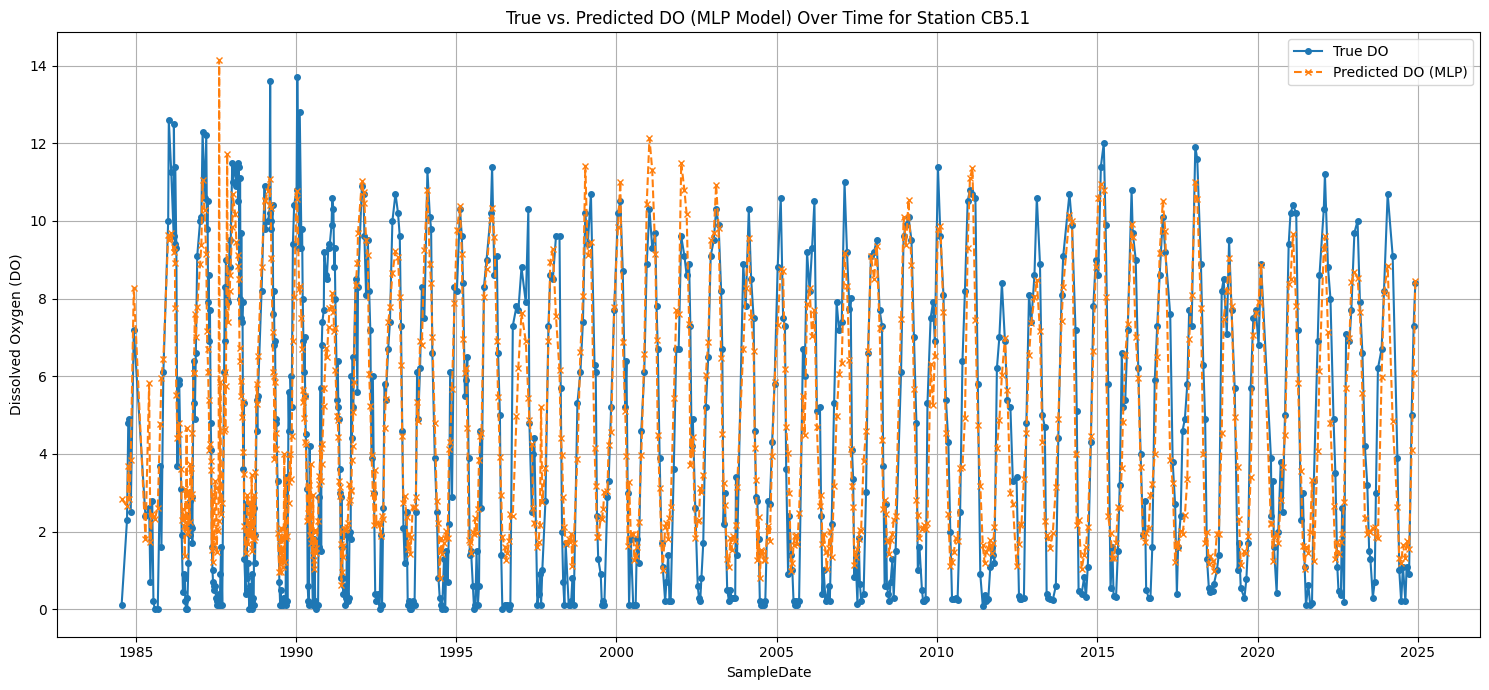

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
# Check if 'SampleDate' is already datetime, if not, convert it
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['MLP_Predicted_DO'], label='Predicted DO (MLP)', marker='x', linestyle='--', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (MLP Model) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: "Please plot SampleDate on the x-axis and compare the true DO and predicted DO values from both the RF and the MLP prediction."

RF_Predicted_DO column re-added to new_data.


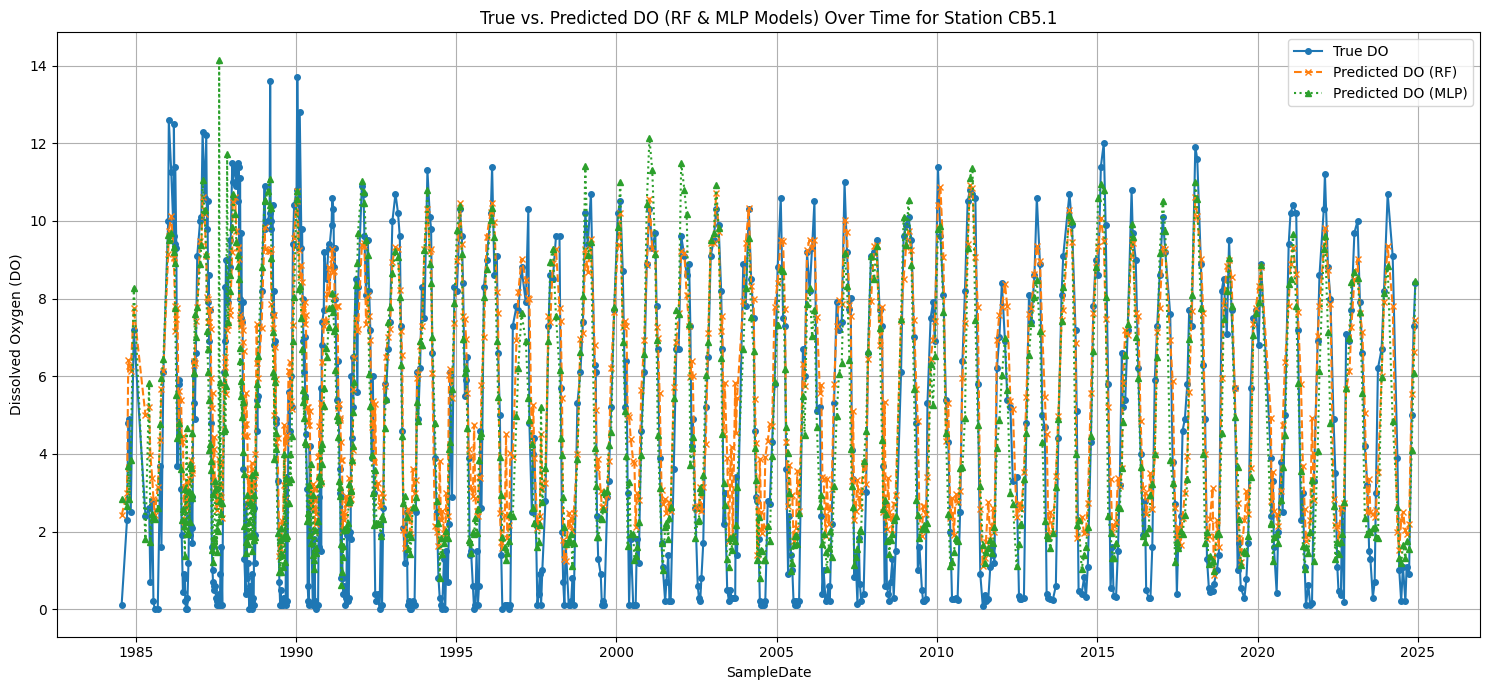

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure SampleDate is in datetime format
# Check if 'SampleDate' is already datetime, if not, convert it
if not pd.api.types.is_datetime64_any_dtype(new_data['SampleDate']):
    new_data['SampleDate'] = pd.to_datetime(new_data['SampleDate'])

# Re-add RF_Predicted_DO to new_data as it might have been overwritten by subsequent cell executions
# The 'predictions' variable from the RF model cell (GUgr4Guz-Uns) should still be available in the kernel state.
if 'predictions' in globals() and 'RF_Predicted_DO' not in new_data.columns:
    new_data['RF_Predicted_DO'] = predictions
    print("RF_Predicted_DO column re-added to new_data.")

plt.figure(figsize=(15, 7))
plt.plot(new_data['SampleDate'], new_data['DO'], label='True DO', marker='o', linestyle='-', markersize=4)
plt.plot(new_data['SampleDate'], new_data['RF_Predicted_DO'], label='Predicted DO (RF)', marker='x', linestyle='--', markersize=4)
plt.plot(new_data['SampleDate'], new_data['MLP_Predicted_DO'], label='Predicted DO (MLP)', marker='^', linestyle=':', markersize=4)

plt.xlabel('SampleDate')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('True vs. Predicted DO (RF & MLP Models) Over Time for Station CB5.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### <font color="#F67">**Congratulations! You’ve completed the “Predict Bottom DO from Surface Variables” module. Great job—you're now a pro at this!**